# Geospatial and Statistical Analysis of Child Placement Patterns in Florida

This execution notebook connects the entire analysis pipeline from raw data to mapping, stats, ML, and AI.


## Step 1 & 2: Data Cleaning and Geospatial ZIP Mapping


In [1]:
import pandas as pd
from IPython.display import display, Image
from scripts.step1_data_cleaning import run as run_step1
from scripts.step2_zip_to_county import run as run_step2

print('Cleaning Data...')
merged = run_step1(save=False)
print('Mapping ZIPs to Counties...')
mapped = run_step2(merged, save=False)
display(mapped.head())


Cleaning Data...
Mapping ZIPs to Counties...


,AFCARS_ID,REMOVAL_DATE,PLACEMENT_BEGIN_DATE,PLACEMENT_END_DATE,PLACEMENT_END_REASON,PLACEMENT_SETTING,SERVICE_CATEGORY,SERVICE_TYPE,LEAD_AGENCY,PROVIDER_NAME_CONFIDENTIAL,...,FL_RACE_HAWAIIAN,FL_RACE_UNBL_DTRMN,FL_RACE_UNKNOWN,FL_RACE_WHITE,FL_MULTI_RCL,indian_tribe,Hispanic,AGE_AT_REMOVAL,PLACEMENT_DURATION_DAYS,COUNTY_NAME
0,000001010299,2012-07-21,2012-07-22,2012-08-23,Reunification w/Parent(s) including Non-,Foster Family Home (Non-Relative),Foster Home,Foster Home - Traditional 0-5,DCF Child Welfare,ONJ. PAY.,...,N,N,N,Y,N,NaN,No\r,1.7,32.0,DUVAL
1,000001010299,2014-09-23,2014-10-06,2014-10-07,Provider Requested Change,Foster Family Home (Non-Relative),Foster Home,LEVEL1 STANDARD 0-11 YEARS OLD,DCF Child Welfare,LEA. LAM.,...,N,N,N,Y,N,NaN,No\r,3.9,1.0,DUVAL
2,000001010299,2014-09-23,2014-10-07,2015-04-01,Provider Requested Change,Foster Family Home (Non-Relative),Foster Home,Foster Home - Traditional 0-5,DCF Child Welfare,LEA. LAM.,...,N,N,N,Y,N,NaN,No\r,3.9,176.0,DUVAL
3,000001010299,2014-09-23,2014-09-23,2014-10-06,Placement Disruption,Foster Family Home (Non-Relative),Foster Home,LEVEL1 STANDARD 0-11 YEARS OLD,DCF Child Welfare,VAL. SHU.,...,N,N,N,Y,N,NaN,No\r,3.9,13.0,CLAY
4,000001010299,2014-09-23,2015-04-01,2015-09-22,Provider Requested Change,Foster Family Home (Non-Relative),Foster Home,LEVEL2 MILD 0-11 YEARS OLD,Family Support Services,LEA. LAM.,...,N,N,N,Y,N,NaN,No\r,3.9,174.0,DUVAL


## Step 3: County Level Aggregation


In [2]:
from scripts.step3_aggregation import run as run_step3
county_data = run_step3(mapped, save=True)
display(county_data.head())


,COUNTY_NAME,children_count,placement_count,avg_placement_duration,avg_age_at_removal,pct_physical_abuse,count_physical_abuse,pct_sexual_abuse,count_sexual_abuse,pct_emotional_abuse_neglect,...,pct_sexual_abuse_sexual_exploitation,count_sexual_abuse_sexual_exploitation,pct_fl_race_black,pct_fl_race_white,pct_fl_race_asian,pct_fl_race_american,pct_fl_race_hawaiian,pct_fl_multi_rcl,pct_hispanic,pct_male
0,ALACHUA,7140,17626,127.079497,8.332250,0.212867,3752,0.069102,1218,0.093158,...,0.000681,12,0.535232,0.497390,0.002950,0.001815,0.000397,0.019290,0.0,0.0
1,BAKER,1128,1711,195.292566,5.412449,0.143776,246,0.024547,42,0.084746,...,0.000000,0,0.202221,0.827586,0.002922,0.001753,0.000000,0.011689,0.0,0.0
2,BAY,5596,12226,150.503979,7.867796,0.146900,1796,0.065025,795,0.069851,...,0.001963,24,0.256584,0.780631,0.004417,0.008179,0.001718,0.024701,0.0,0.0
3,BRADFORD,1283,1961,179.252999,6.584729,0.198878,390,0.047425,93,0.103519,...,0.000510,1,0.329934,0.726670,0.003570,0.002040,0.000000,0.015808,0.0,0.0
4,BREVARD,14343,39622,140.087234,8.496448,0.131291,5202,0.046313,1835,0.104588,...,0.001767,70,0.335622,0.721745,0.003634,0.002524,0.000909,0.014992,0.0,0.0


## Step 4: GIS Choropleth Mapping


Generating Maps...


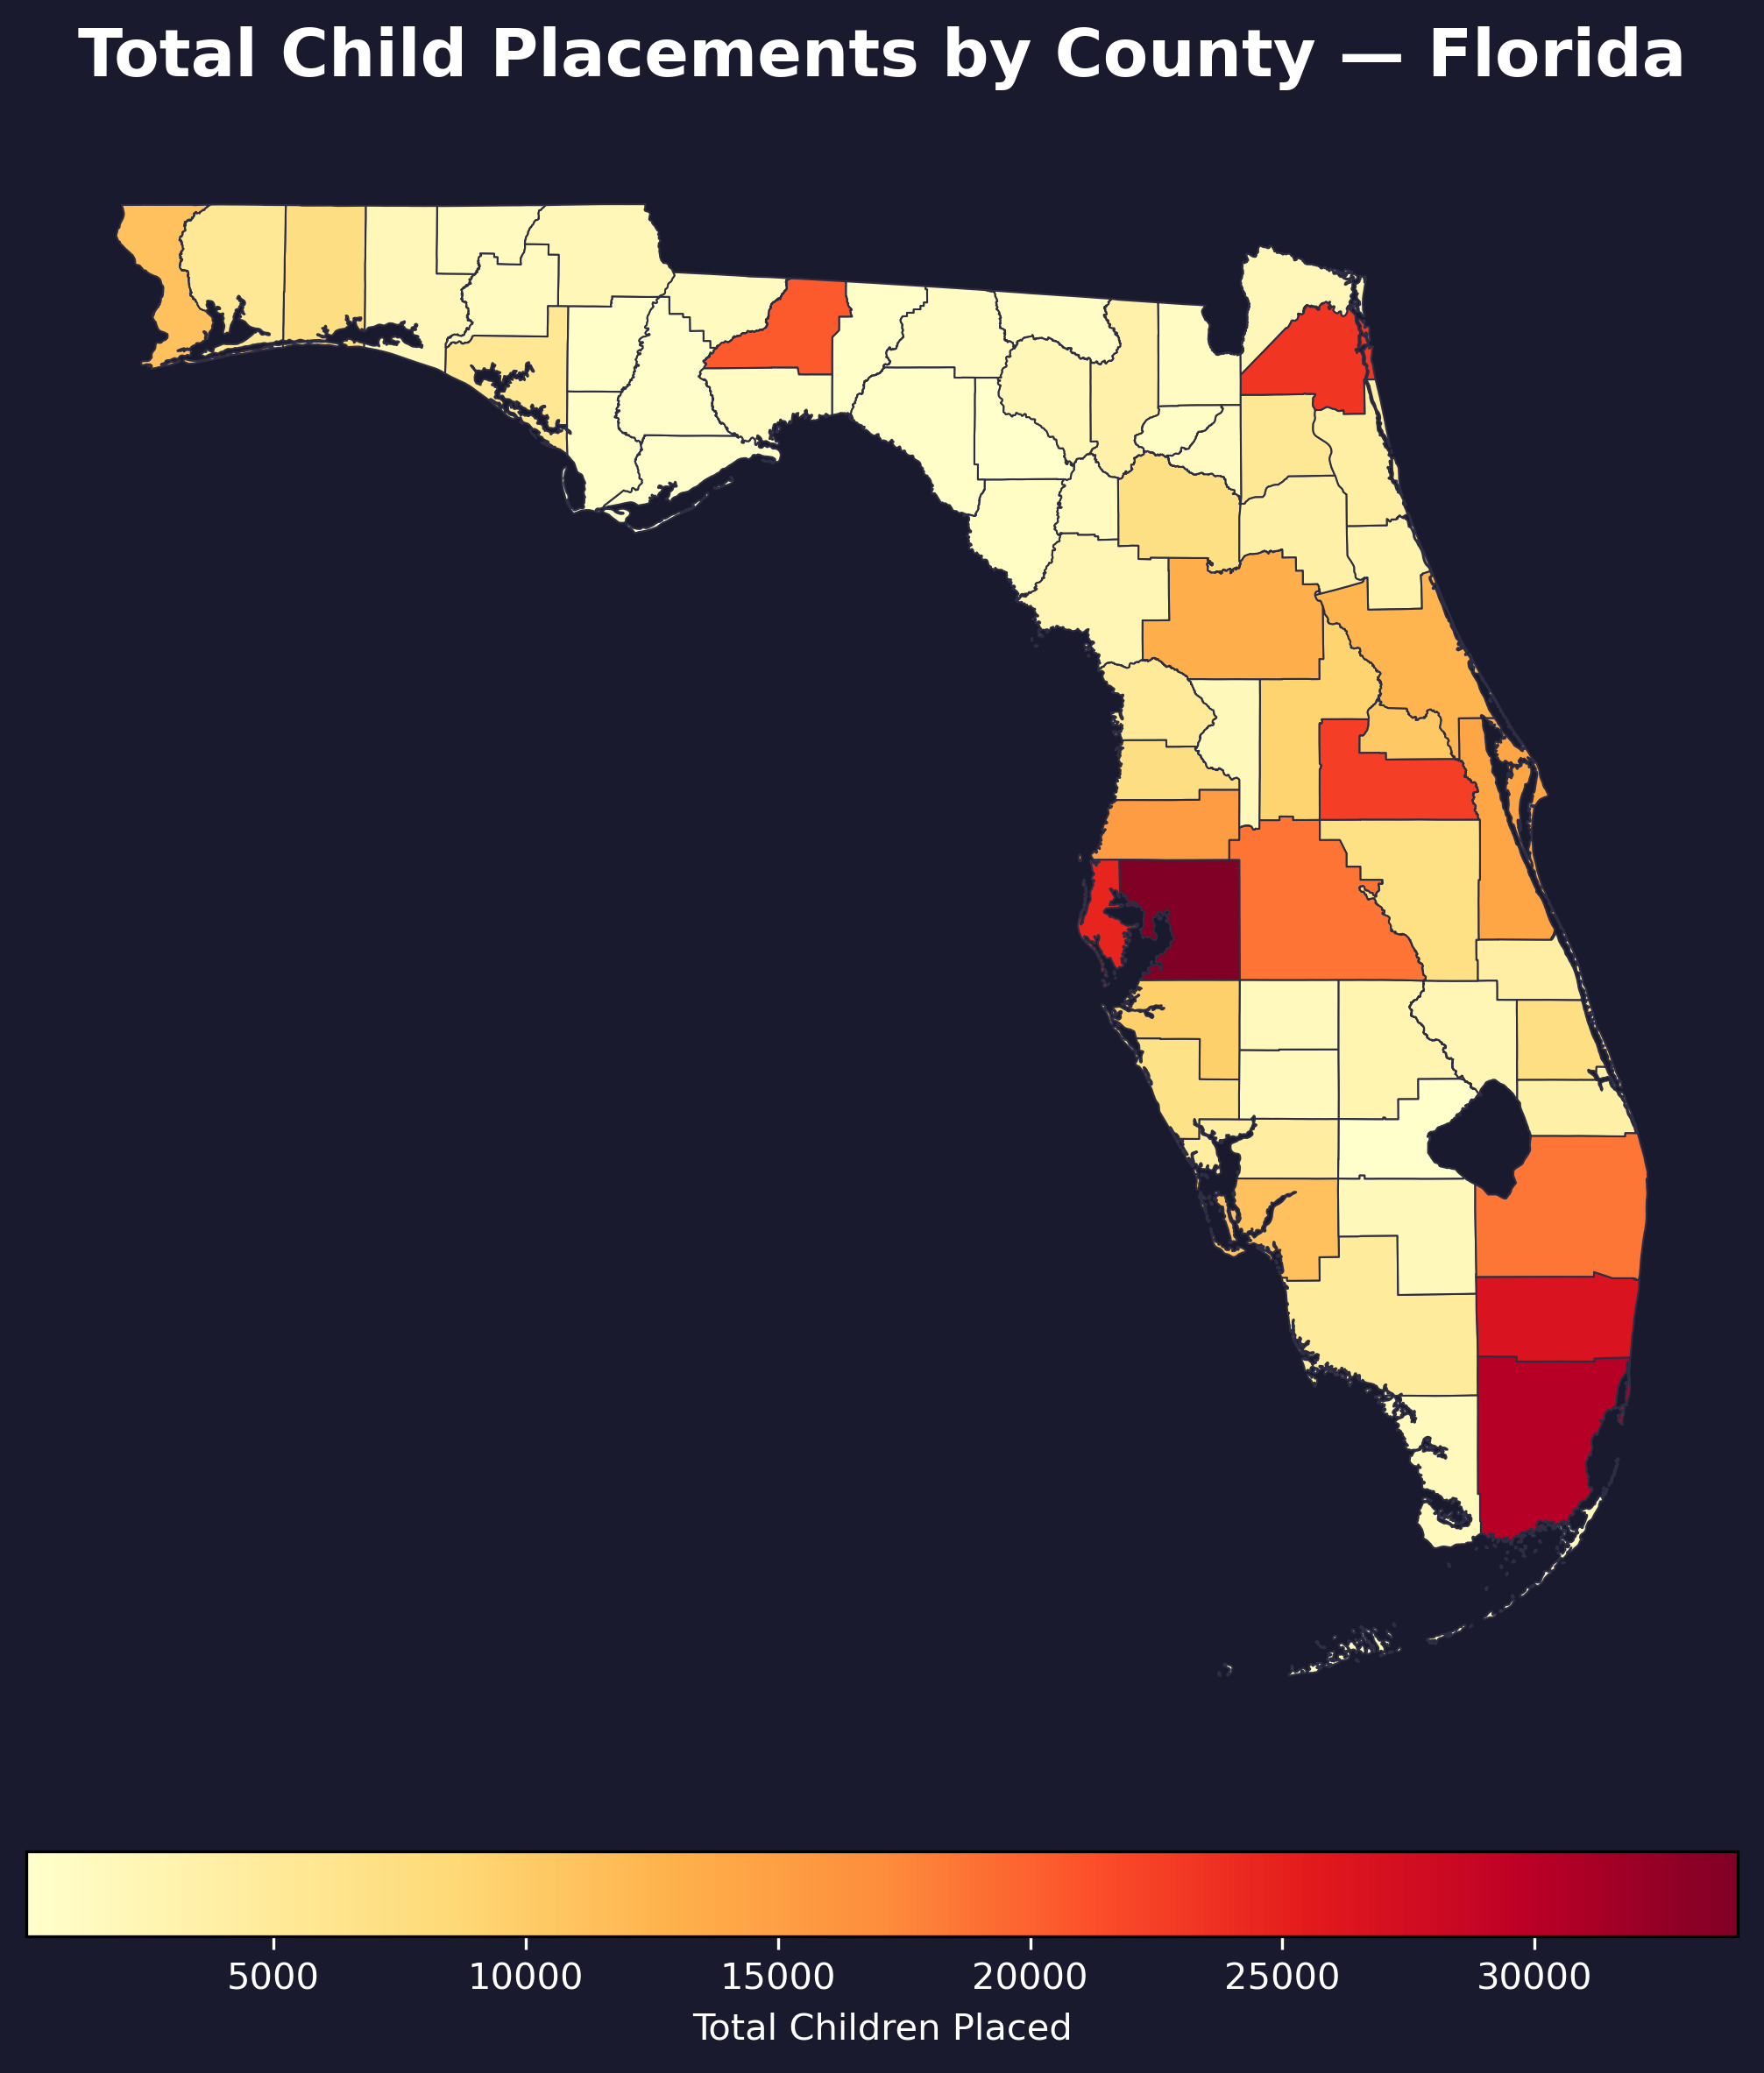

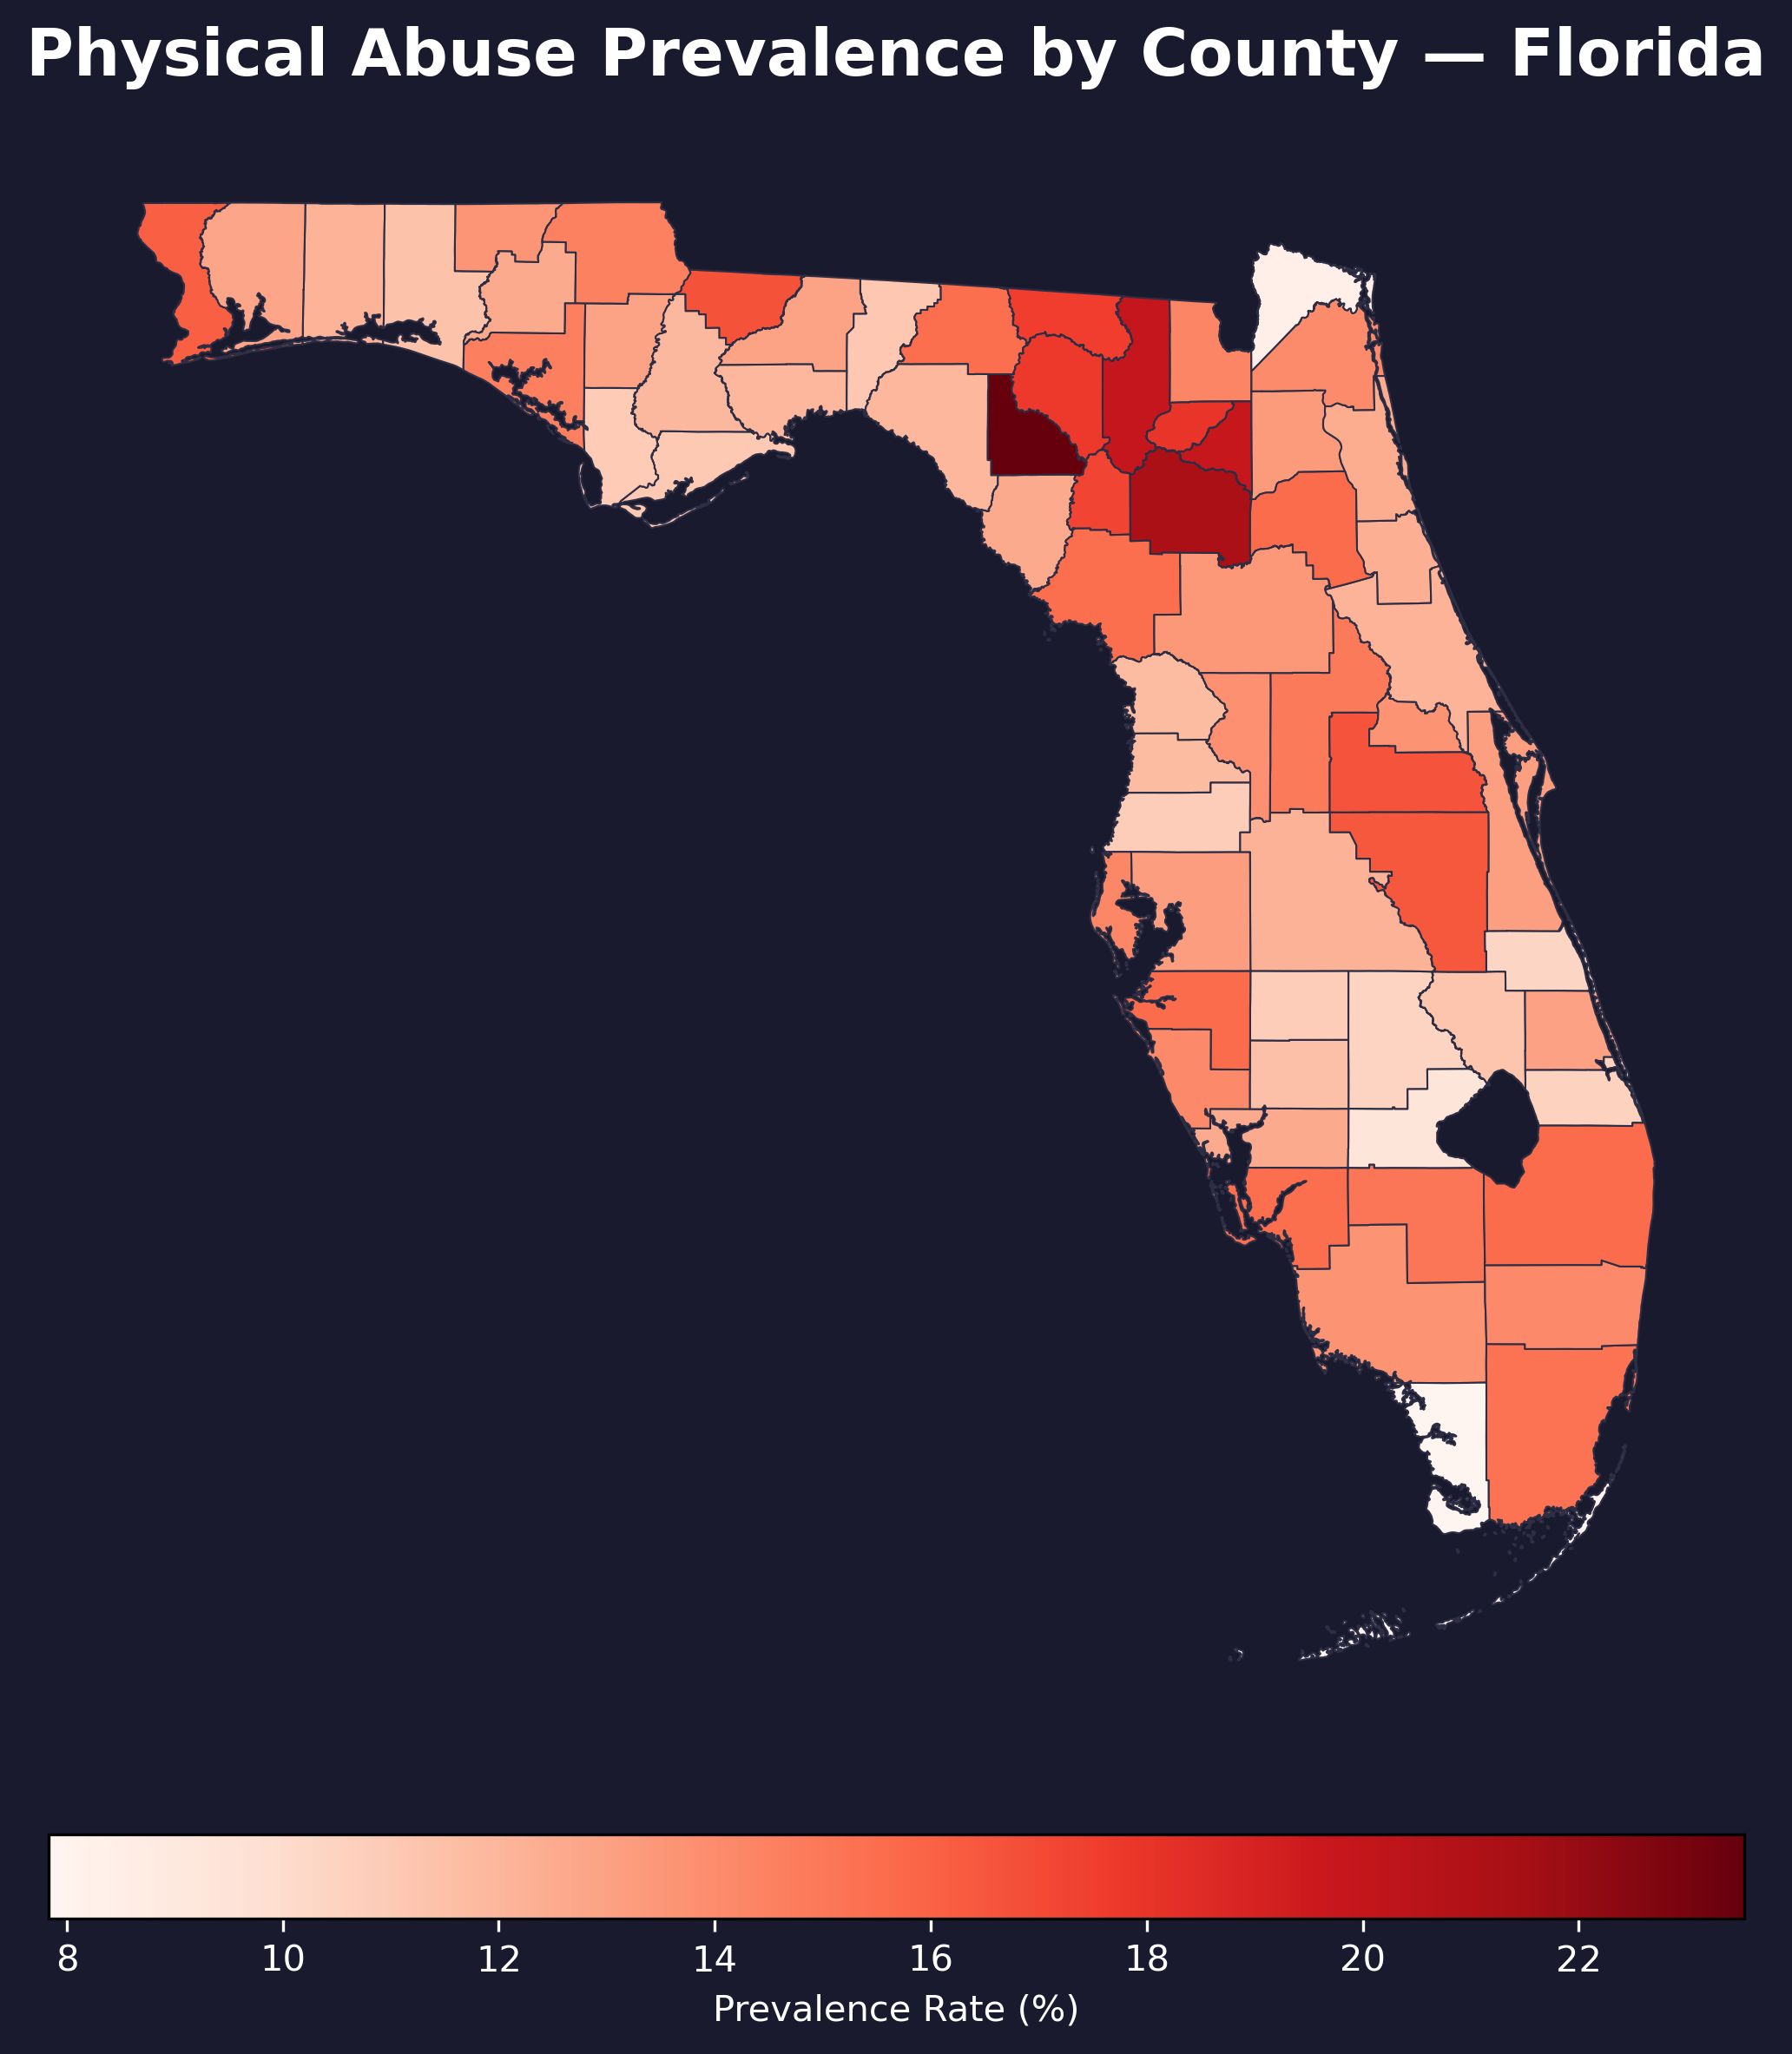

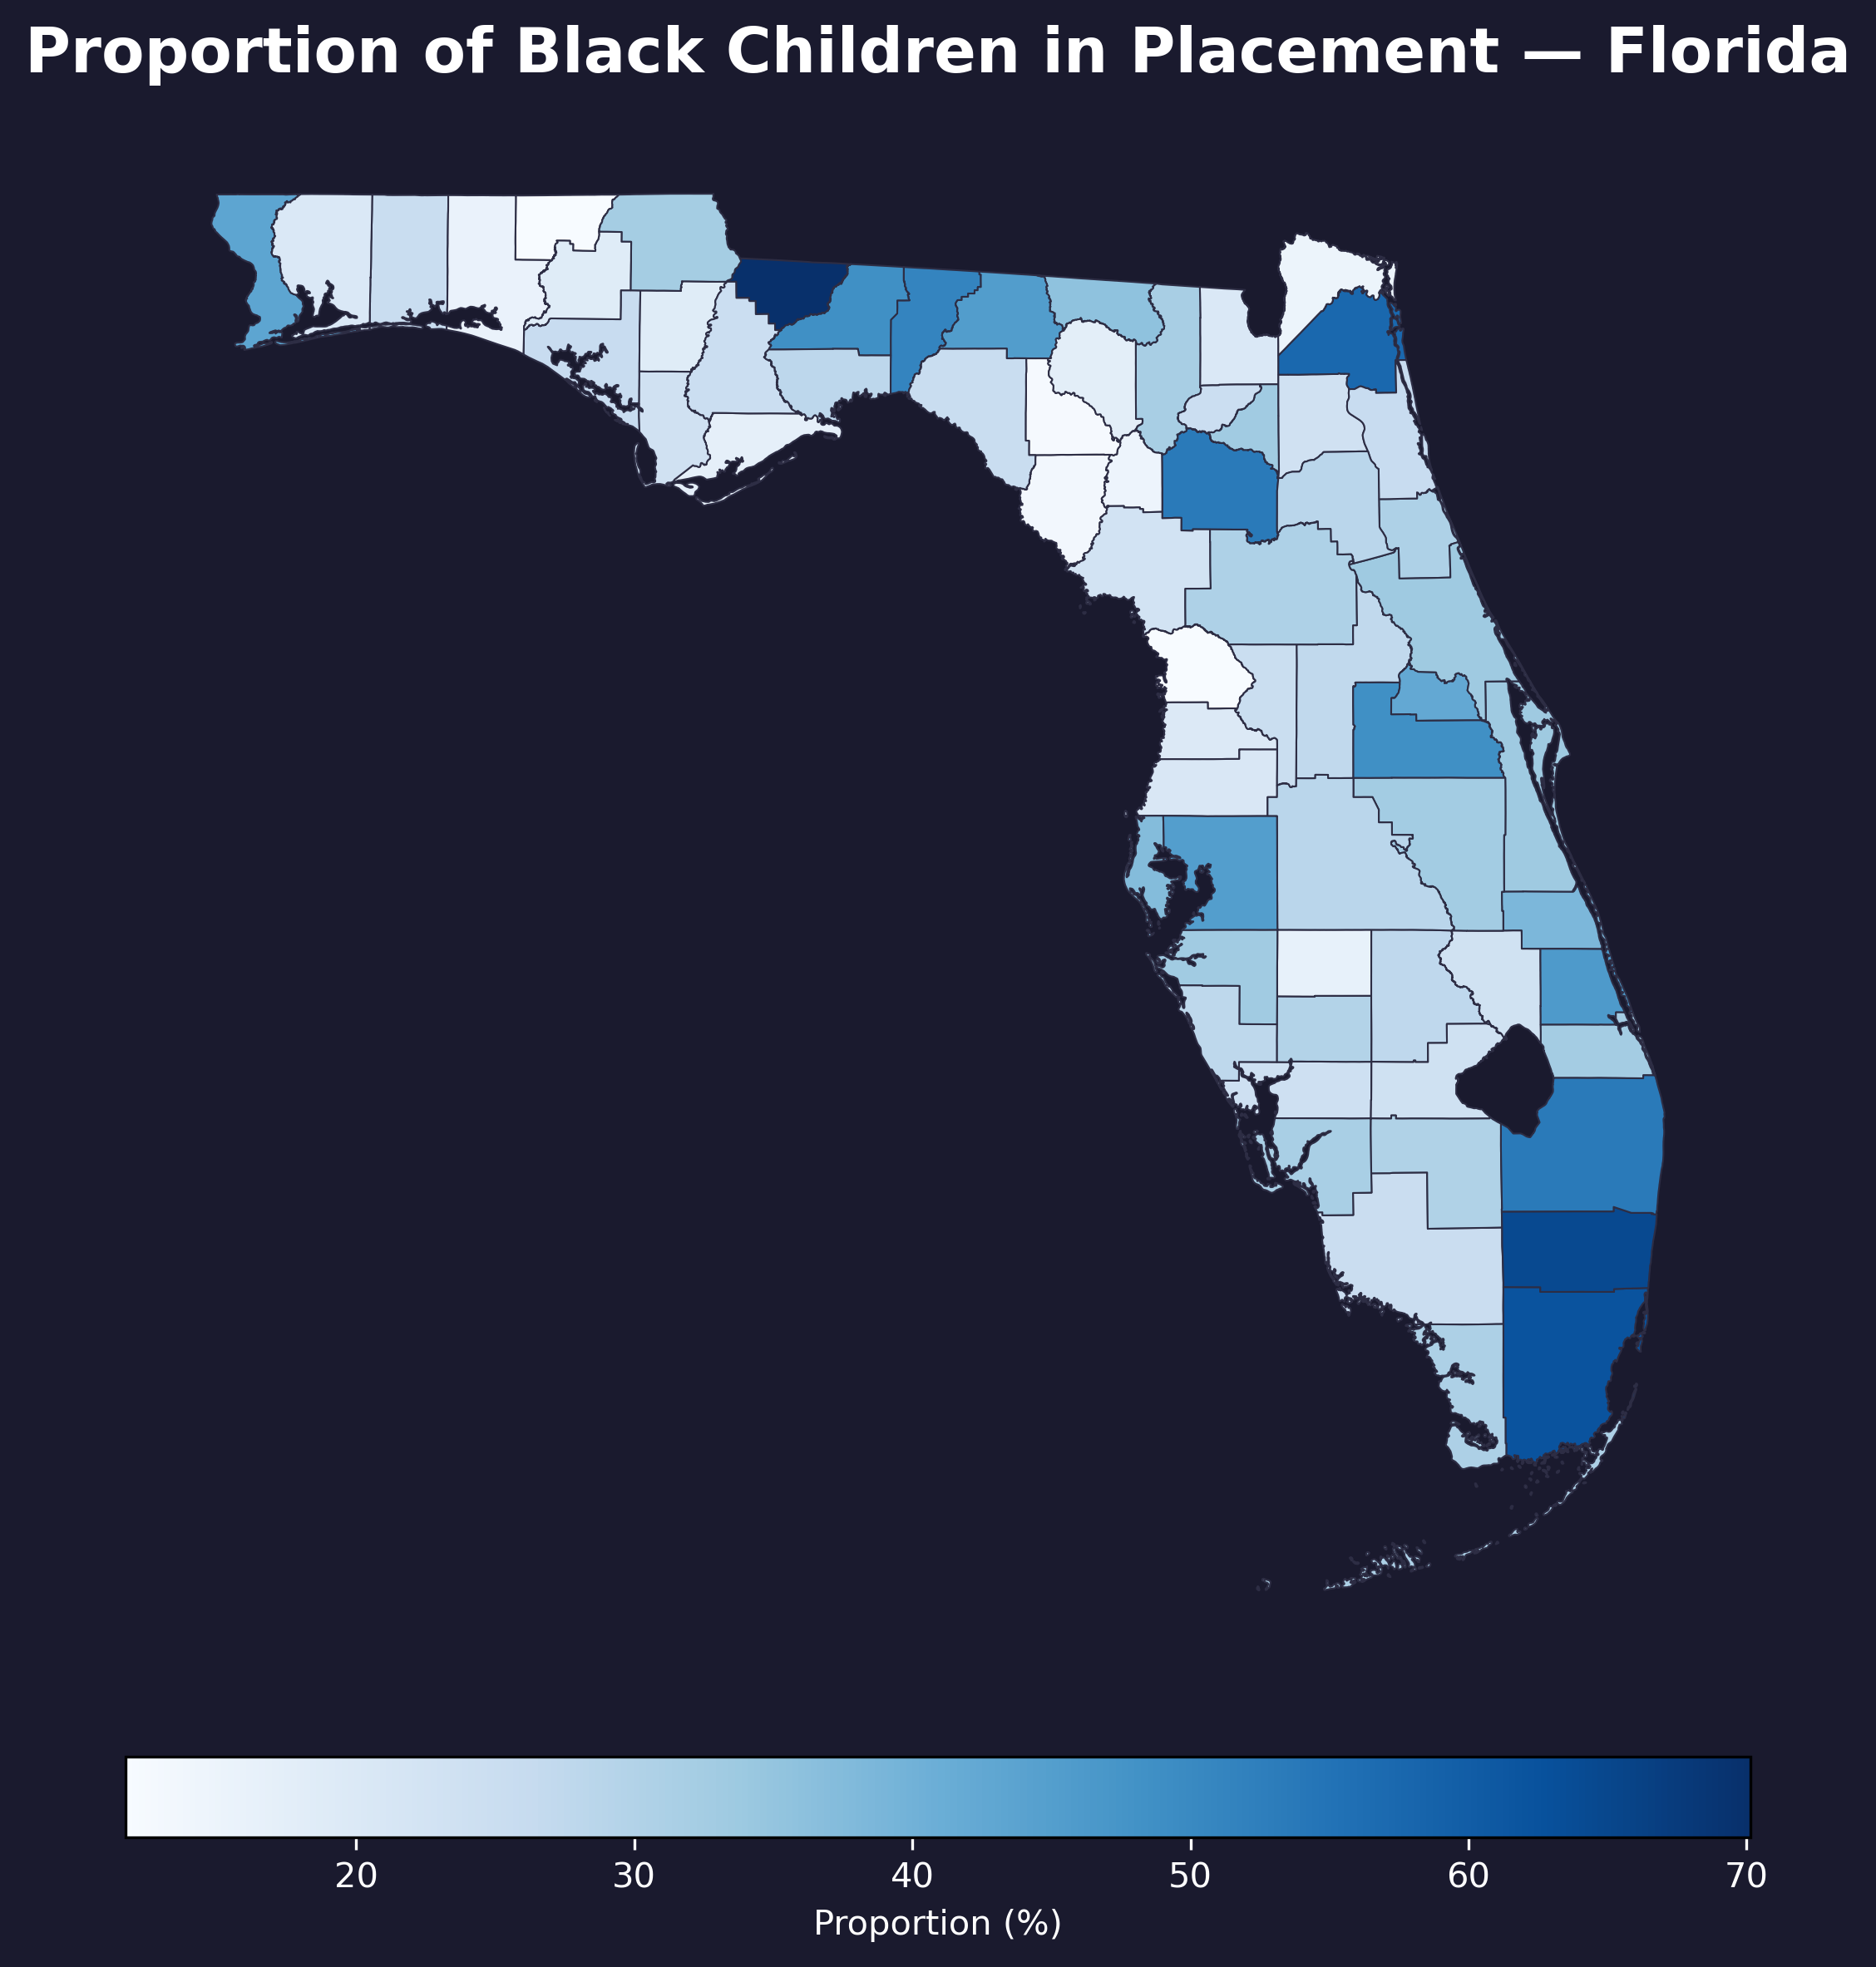

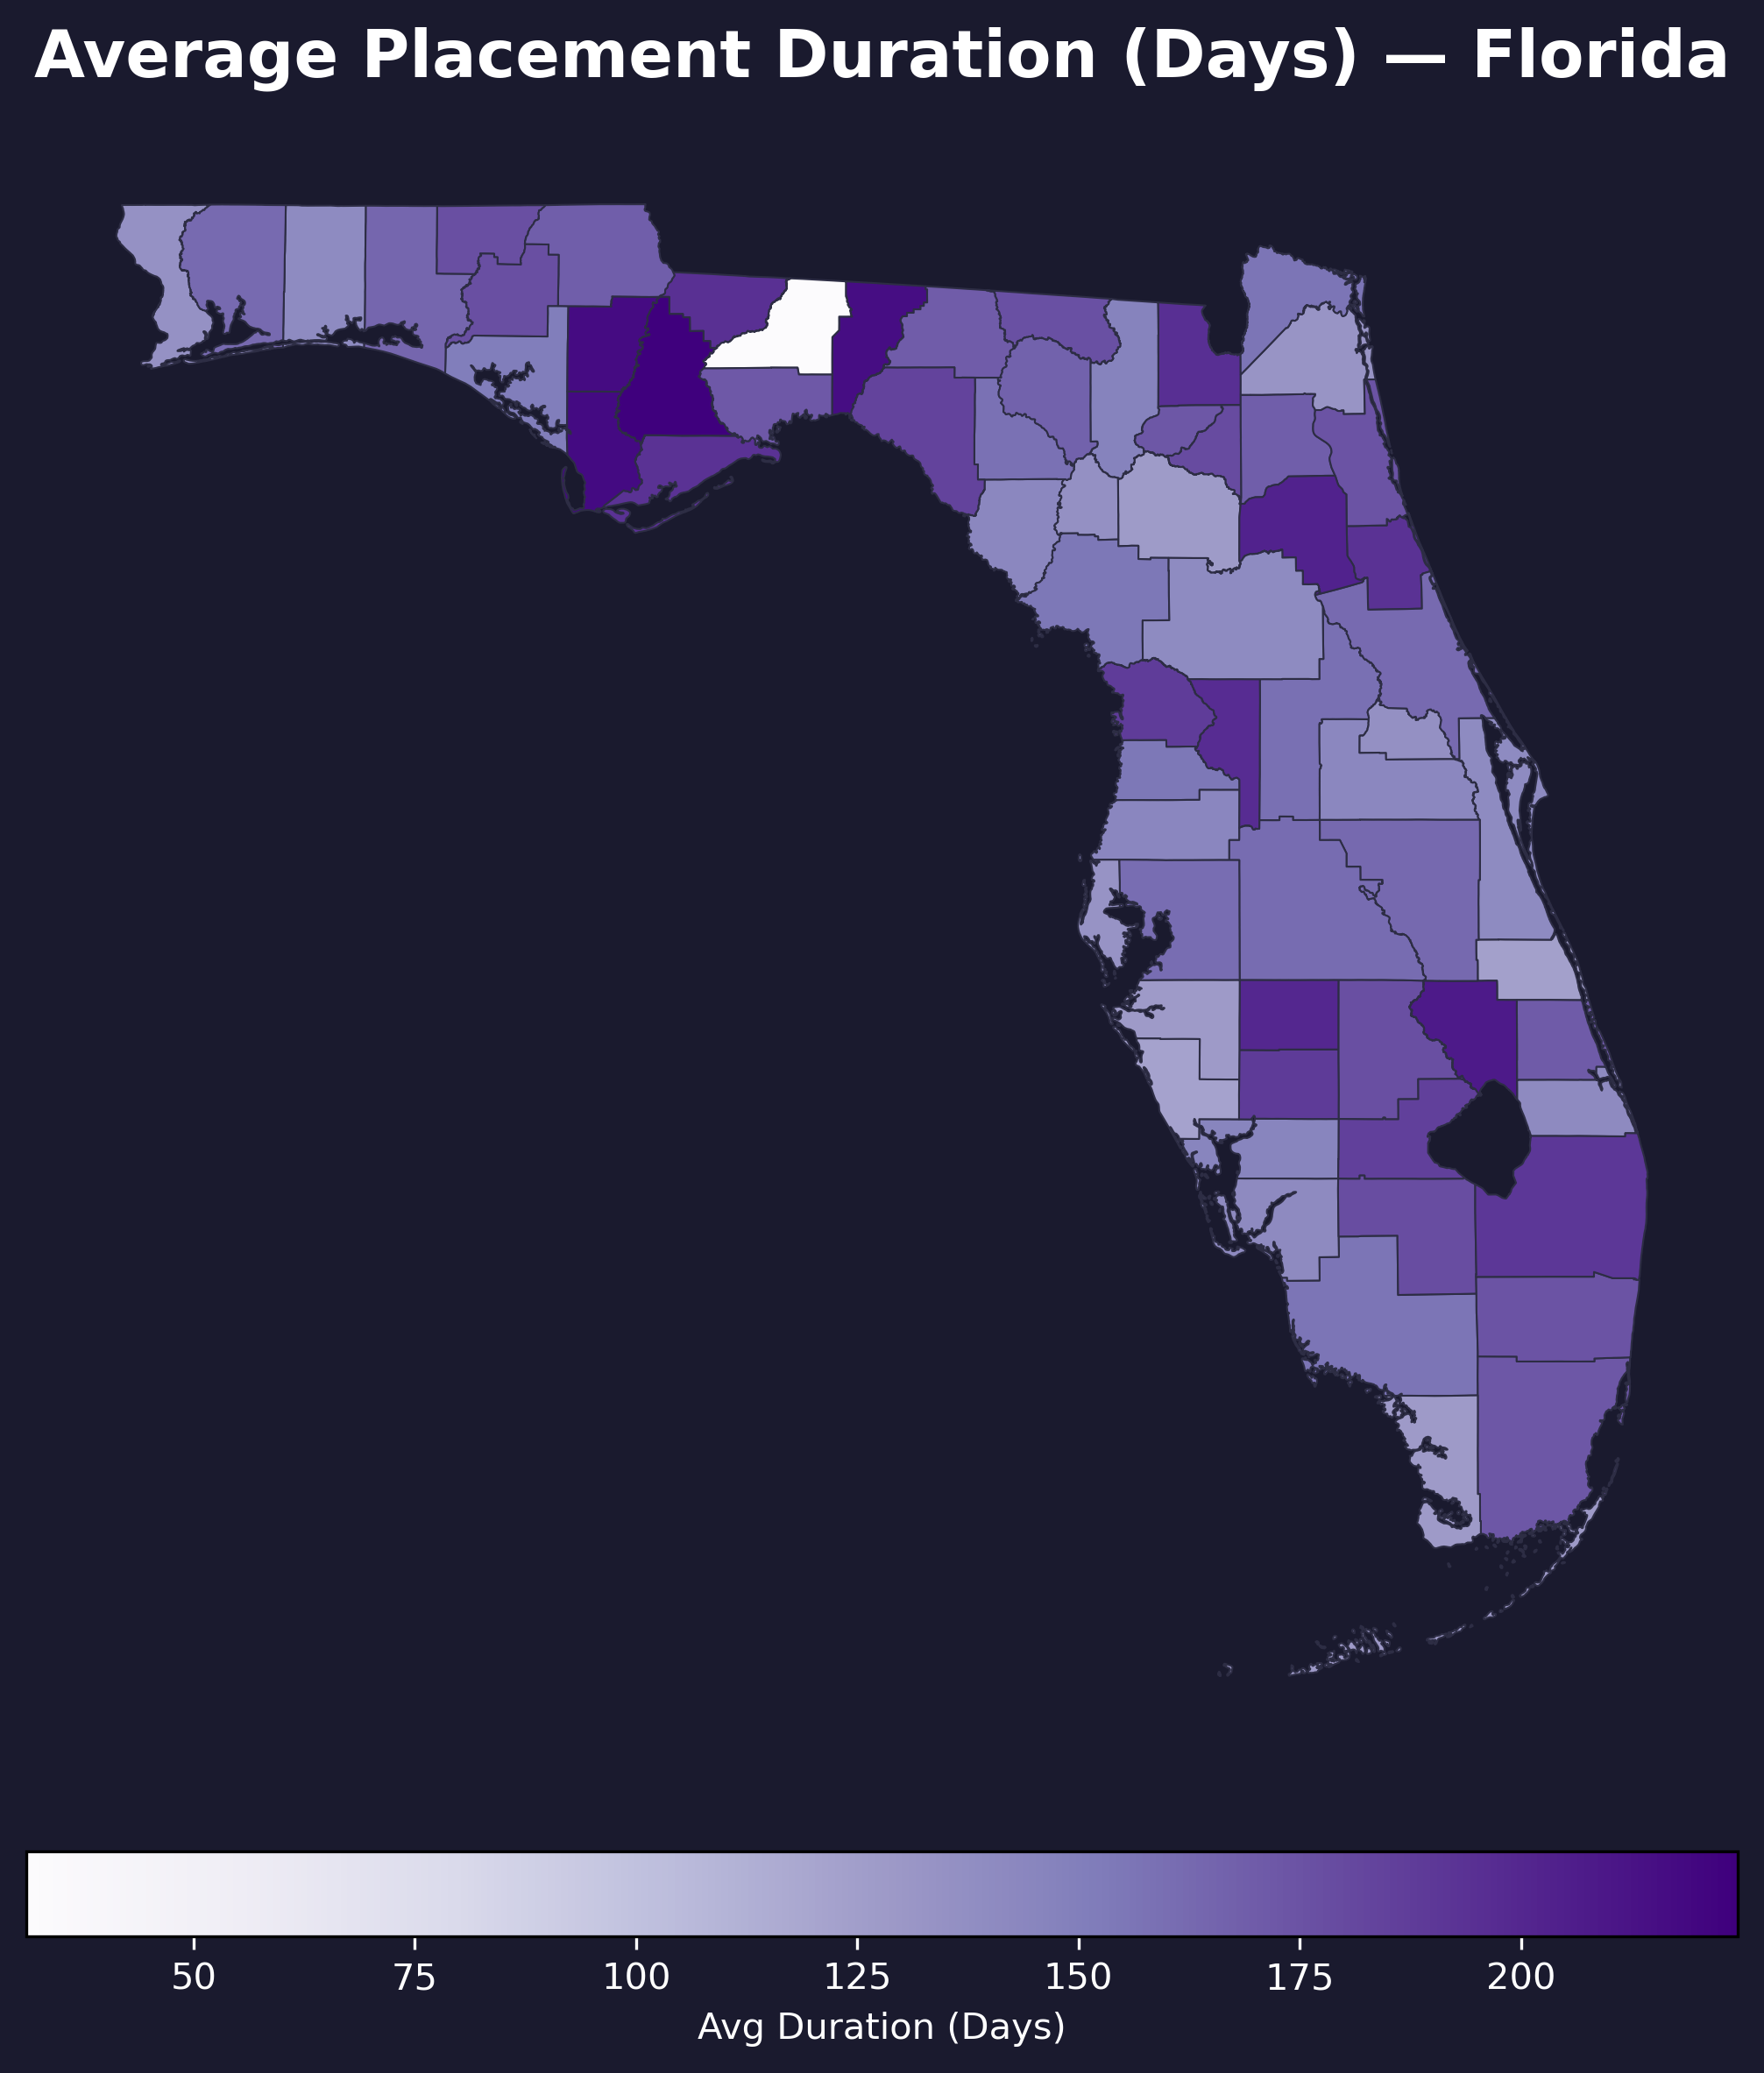

In [3]:
from scripts.step4_gis_mapping import run as run_step4

print('Generating Maps...')
gdf = run_step4(county_data)
display(Image(filename='outputs/maps/choropleth_children_count.png'))
display(Image(filename='outputs/maps/choropleth_maltreatment.png'))
display(Image(filename='outputs/maps/choropleth_demographics.png'))
display(Image(filename='outputs/maps/choropleth_duration.png'))


## Step 5: Statistical Analysis (R)


Executing R Statistical Scripts...


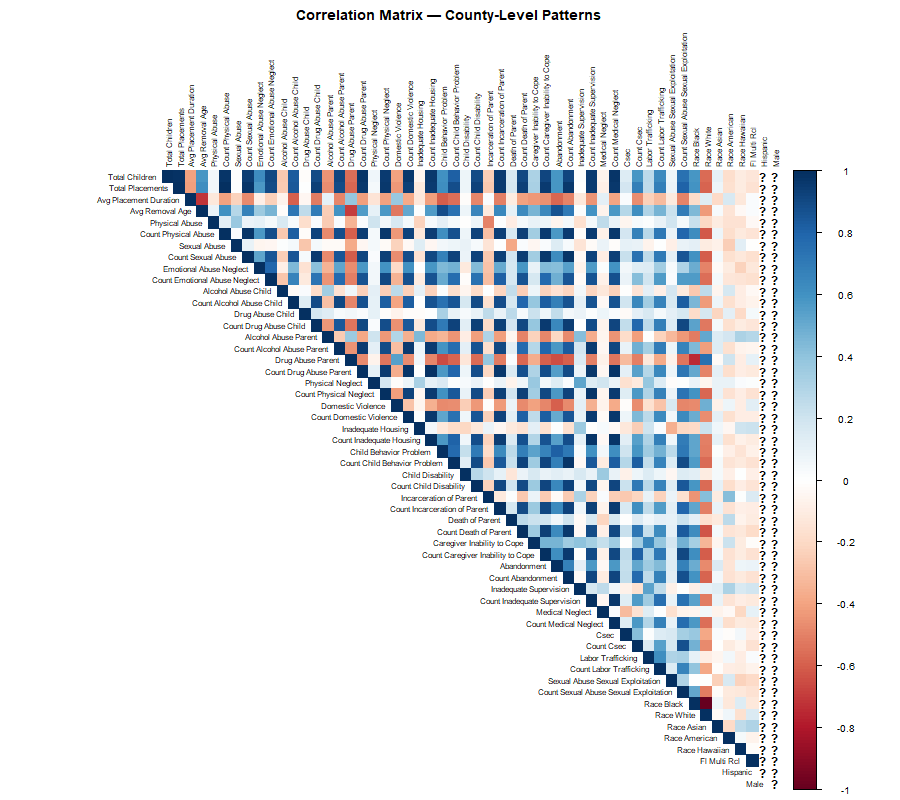

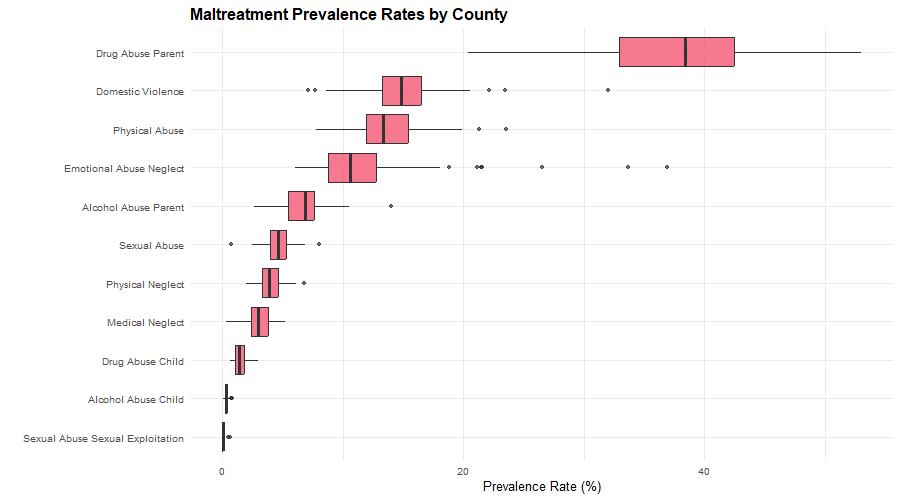


--- STATS OUTPUT ---
  STATISTICAL REPORT — Child Placement by Florida County
  Generated: 2026-03-19 14:05:55 

--- Descriptive Statistics (children_count) ---
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    100    1360    3563    6885    9378   34024 

SD: 8072.919 

--- Regression Model ---

Call:
lm(formula = as.formula(formula_str), data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-13446.1  -3834.4   -967.2   2940.0  19547.8 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)              34313       7512   4.568  2.4e-05 ***
pct_physical_abuse      -34904      35236  -0.991 0.325740    
pct_physical_neglect     40127      79379   0.506 0.614993    
pct_domestic_violence   -18231      30307  -0.602 0.549671    
pct_drug_abuse_parent   -57204      15296  -3.740 0.000404 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6803 on 62 degrees of freedom
Multiple R-squared:  

In [4]:
import subprocess
print('Executing R Statistical Scripts...')
subprocess.run([r'C:\Program Files\R\R-4.5.3\bin\Rscript.exe', 'scripts/step5_statistical_analysis.R'])

display(Image(filename='outputs/stats/correlation_matrix.png'))
display(Image(filename='outputs/stats/boxplot_maltreatment.png'))

print('\n--- STATS OUTPUT ---')
with open('outputs/stats/r_analysis_output.txt', 'r') as f:
    print(f.read())


## Step 6: Machine Learning Classification (Random Forest)
Classifying High-Risk vs Low-Risk counties.


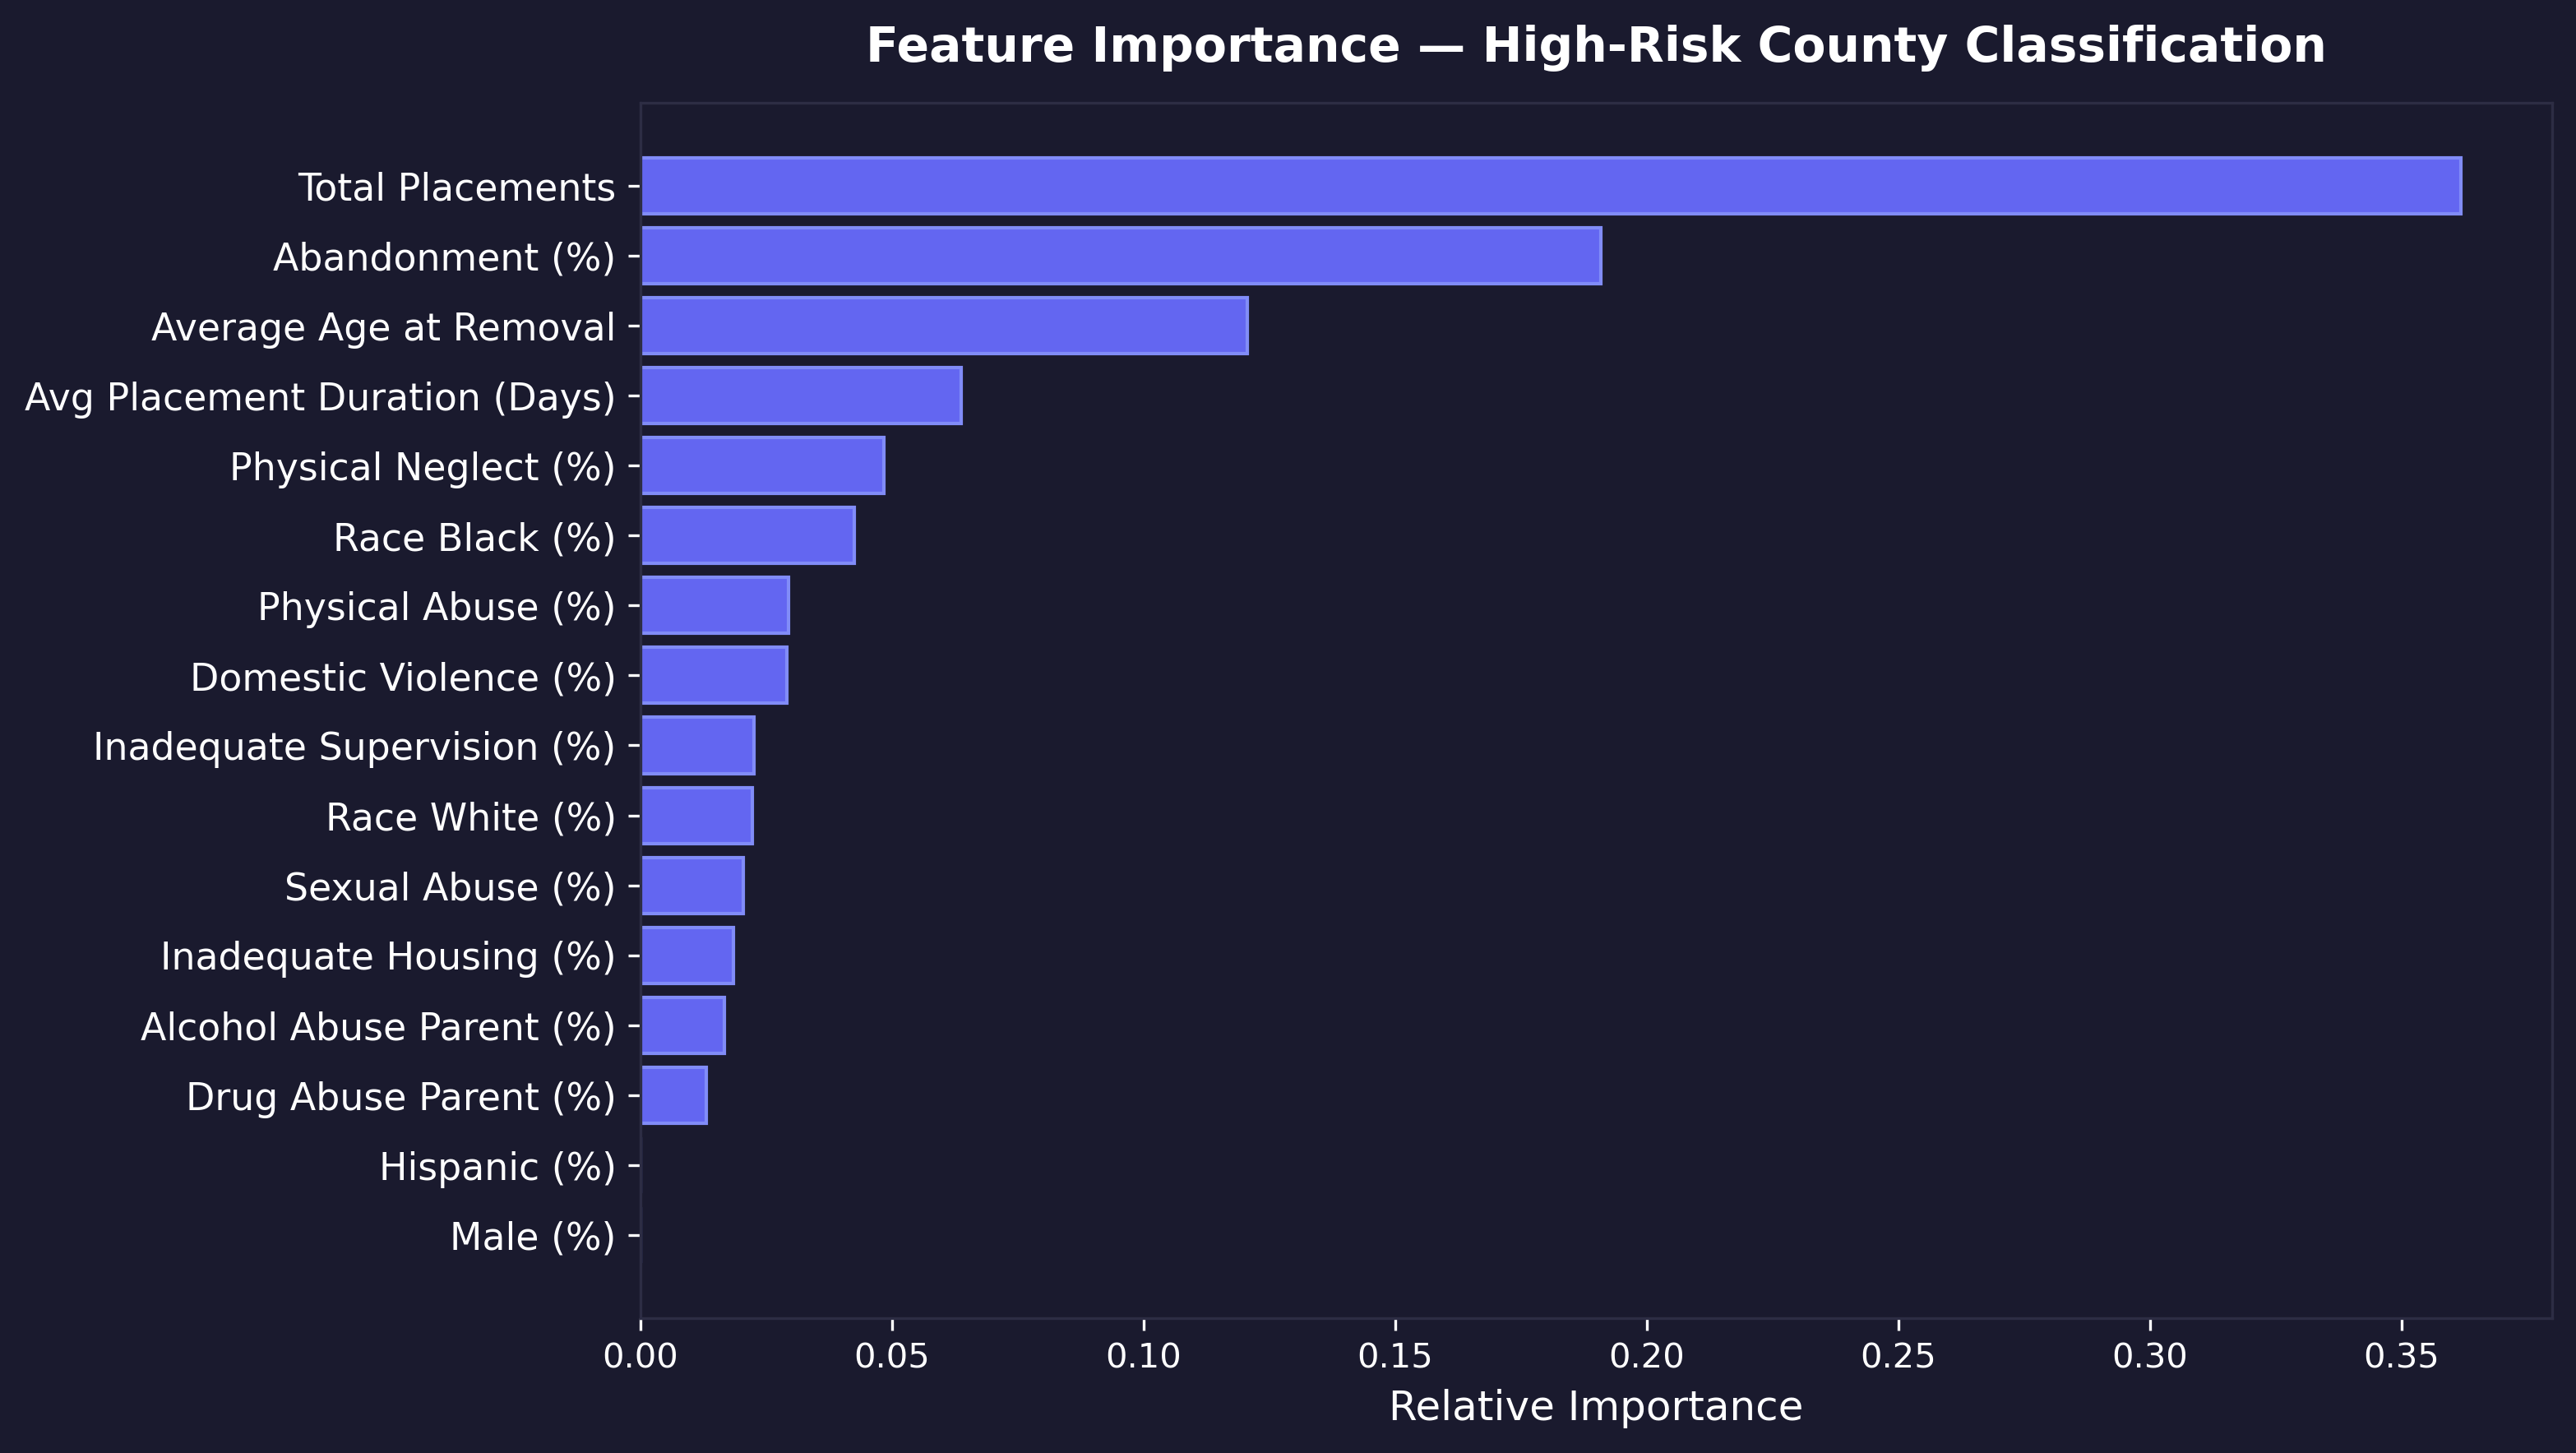

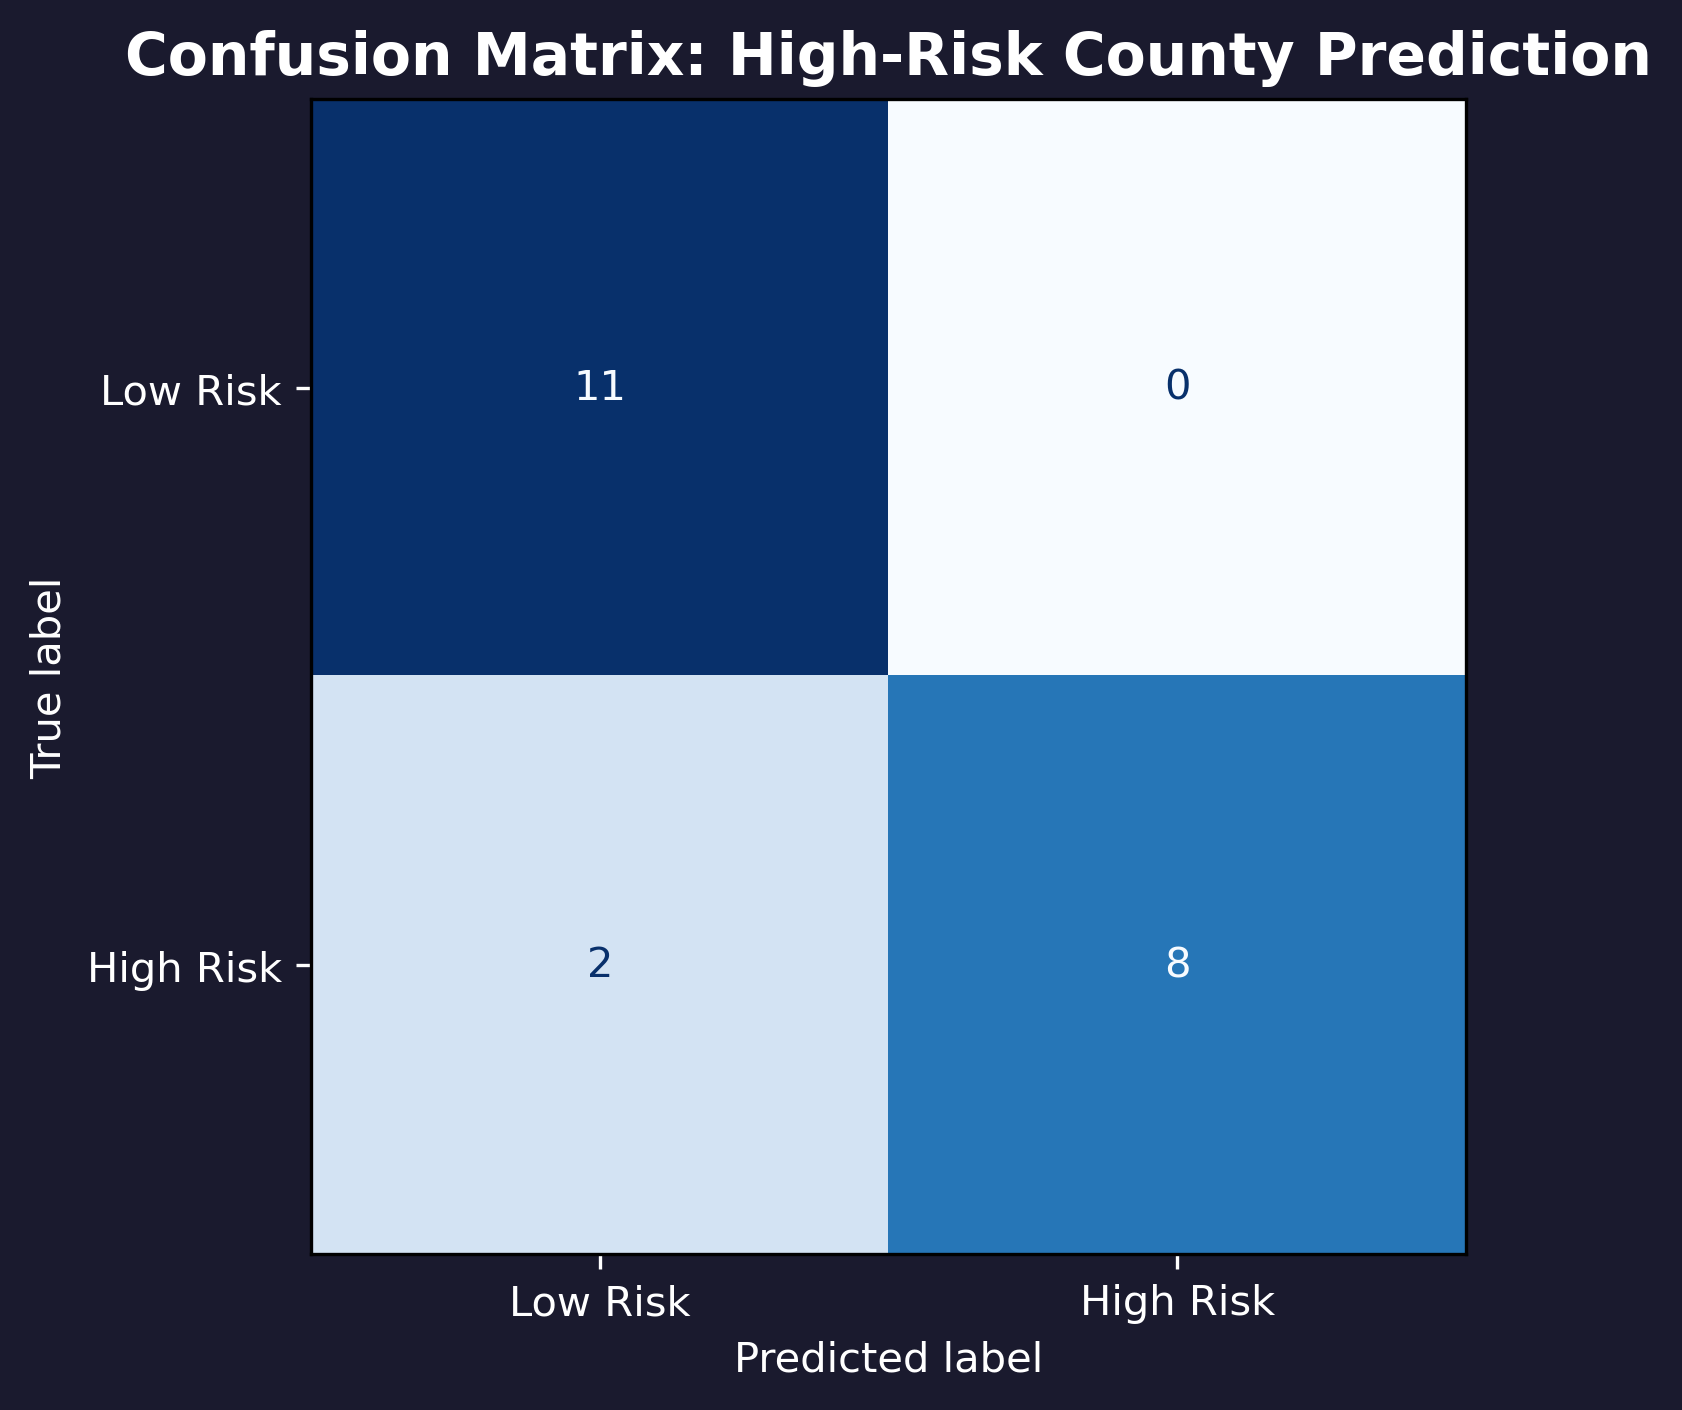

  RANDOM FOREST CLASSIFICATION REPORT

              precision    recall  f1-score   support

    Low Risk       0.85      1.00      0.92        11
   High Risk       1.00      0.80      0.89        10

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21

CV Accuracy: 0.941 ± 0.054

Median Threshold: 3563.0
Training samples: 46
Test samples:     21

Features used:
  pct_male                                 0.0000
  pct_hispanic                             0.0000
  pct_drug_abuse_parent                    0.0131
  pct_alcohol_abuse_parent                 0.0167
  pct_inadequate_housing                   0.0185
  pct_sexual_abuse                         0.0204
  pct_fl_race_white                        0.0222
  pct_inadequate_supervision               0.0226
  pct_domestic_violence                    0.0292
  pct_physical_abuse                       0.0294
  pct_fl_race_black    

In [5]:
from scripts.step6_ml_classification import run as run_step6
results = run_step6(county_data, save=True)
display(Image(filename='outputs/ml/feature_importance.png'))
display(Image(filename='outputs/ml/confusion_matrix.png'))

with open('outputs/ml/model_metrics.txt', 'r') as f:
    print(f.read())


## Step 7: PowerBI Export
Generates Star-Schema ready CSVs for ingestion into Microsoft PowerBI.


In [6]:
from scripts.step7_powerbi_export import run as run_step7
run_step7()


## Step 8: AI Layer (Unsupervised Clustering)
Deploys K-Means AI clustering to construct contextual safety archetypes across Florida counties.


c:\Users\srira\anaconda3\envs\cnd_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


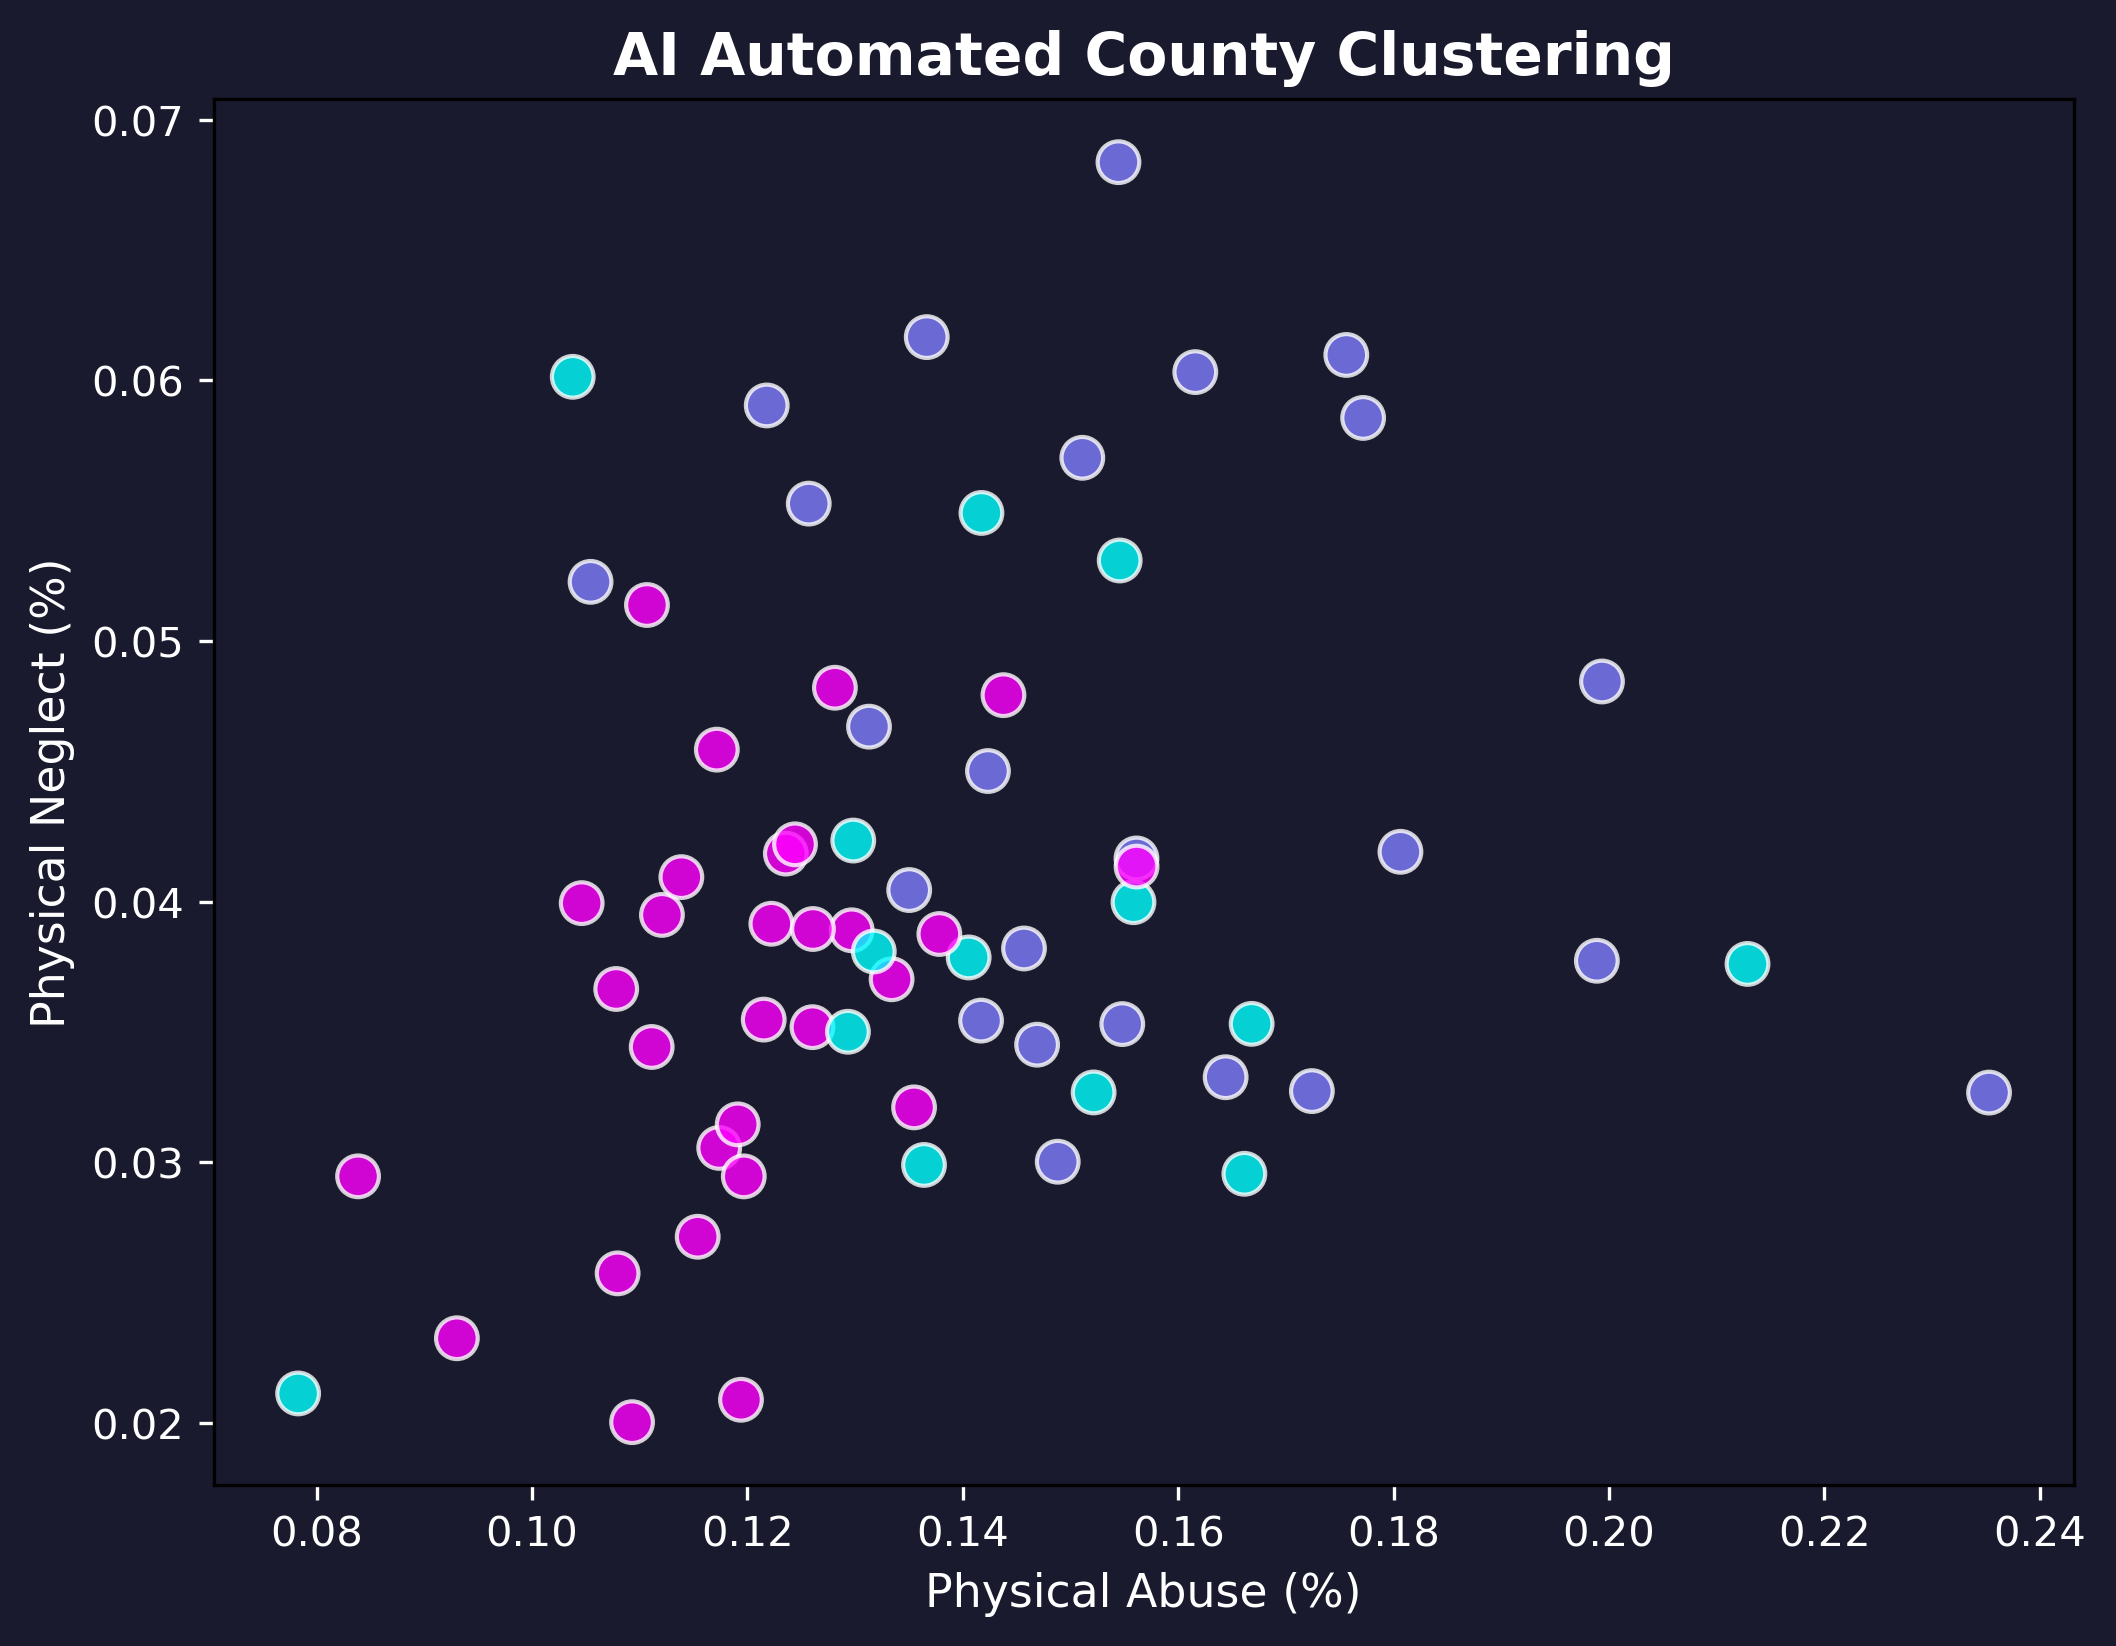

,COUNTY_NAME,AI_Archetype
0,ALACHUA,Standard Profile
1,BAKER,Chronic Long-Term Care
2,BAY,Standard Profile
3,BRADFORD,Standard Profile
4,BREVARD,Standard Profile
5,BROWARD,Standard Profile
6,CALHOUN,Chronic Long-Term Care
7,CHARLOTTE,Standard Profile
8,CITRUS,Chronic Long-Term Care
9,CLAY,Chronic Long-Term Care


In [7]:
from scripts.step8_ai_layer import run as run_step8
ai_data = run_step8(county_data, save=True)
display(Image(filename='outputs/ai_insights/ai_cluster_scatter.png'))
display(ai_data[['COUNTY_NAME', 'AI_Archetype']].head(10))
